# Task 1: Clustering
 Dataset: Iris

 Requirements:
  - Apply K-Means clustering 
  - Use the Elbow Method to determine optimal number of clusters 
  - Evaluate clustering performance using:
     - Inertia
     - Silhouette Score
        -  Visualize clusters
        -  Compare cluster assignments with actual labels 
        - Provide analysis of results

In [1]:
# import libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

from sklearn.decomposition import PCA

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [ ]:
# load iris dataset

iris = load_iris()

X = iris.data
y = iris.target

feature_names = iris.feature_names
target_names = iris.target_names

print("Feature Names:")
print(feature_names)
print("\nTarget Names:")
print(target_names)

Feature Names:
['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']

Target Names:
['setosa' 'versicolor' 'virginica']


In [3]:
# create dataframe

df = pd.DataFrame(X, columns=feature_names)

df["target"] = y

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [4]:
# dataset information

print("Dataset Shape:")
print(df.shape)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nTarget Counts:")
print(df["target"].value_counts())

Dataset Shape:
(150, 5)

Missing Values:
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
target               0
dtype: int64

Target Counts:
target
0    50
1    50
2    50
Name: count, dtype: int64


In [5]:
# feature scaling:
#  KMeans depends on distances
# large-value features dominate otherwise

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print(X_scaled[:5])

[[-0.90068117  1.01900435 -1.34022653 -1.3154443 ]
 [-1.14301691 -0.13197948 -1.34022653 -1.3154443 ]
 [-1.38535265  0.32841405 -1.39706395 -1.3154443 ]
 [-1.50652052  0.09821729 -1.2833891  -1.3154443 ]
 [-1.02184904  1.24920112 -1.34022653 -1.3154443 ]]


# Understanding Elbow Method

The Elbow Method refers to either a visual heuristic in machine learning used to determine the optimal number of clusters for algorithms like K-Means.

In [6]:
# we calculate inertia for multiple k values.

inertia_values = []

K_range = range(1, 11)

for k in K_range:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)

    inertia_values.append(kmeans.inertia_)

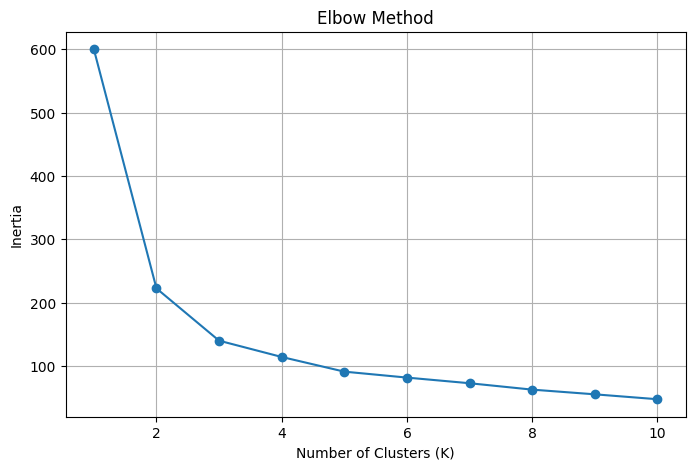

In [7]:
# plot elbow method

plt.figure(figsize=(8,5))

plt.plot(K_range, inertia_values, marker='o')

plt.title("Elbow Method")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")

plt.grid(True)

plt.show()

In [8]:
# Explanation of elbow method:

print("""
ELBOW METHOD ANALYSIS

We plot:
- Number of clusters (K)
vs
- Inertia

Goal:
Find the 'elbow point' where inertia reduction slows down.

For Iris dataset:
K=3 is usually the optimal cluster count.

Reason:
Iris dataset contains 3 natural flower classes.
""")


ELBOW METHOD ANALYSIS

We plot:
- Number of clusters (K)
vs
- Inertia

Goal:
Find the 'elbow point' where inertia reduction slows down.

For Iris dataset:
K=3 is usually the optimal cluster count.

Reason:
Iris dataset contains 3 natural flower classes.



# Now, apply K-means with optimal k i.e k=3 

In [9]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

kmeans.fit(X_scaled)

cluster_labels = kmeans.labels_

print(cluster_labels[:20])

[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]


means:
The first 20 flowers were assigned to Cluster 1.

In [10]:
print(cluster_labels[:150])

[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 0 0 0 2 0 0 0 0 0 0 0 0 2 0 0 0 0 2 0 0 0
 0 2 2 2 0 0 0 0 0 0 0 2 2 0 0 0 0 0 0 0 0 0 0 0 0 0 2 0 2 2 2 2 0 2 2 2 2
 2 2 0 0 2 2 2 2 0 2 0 2 0 2 2 0 2 2 2 2 2 2 0 0 2 2 2 0 2 2 2 0 2 2 2 0 2
 2 0]


In [11]:
# Adding cluster labels to the original dataframe

df["cluster"] = cluster_labels

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,cluster
0,5.1,3.5,1.4,0.2,0,1
1,4.9,3.0,1.4,0.2,0,1
2,4.7,3.2,1.3,0.2,0,1
3,4.6,3.1,1.5,0.2,0,1
4,5.0,3.6,1.4,0.2,0,1


# calculate Inertia

Inertia measures:
 how closely data points are grouped within their clusters.

It is calculated as:
- the sum of distances between each data point and its cluster center (centroid).

Inertia=∑​∣∣xi​−ci​∣∣^2

        where:
            xi = data point
            ci= nearest cluster centroid 
            ||xi - ci||^2 = squared Euclidean distance

Lower inertia means:
- points are closer to their cluster centers
- clusters are more compact and organized

Higher inertia means:
- points are more spread out
- clustering quality is weaker

In [12]:
print("Final Inertia:")
print(kmeans.inertia_)

Final Inertia:
139.8204963597498


This indicates that:
- the Iris data points are reasonably close to their cluster centers
- K-Means successfully formed compact clusters

However, inertia alone cannot determine whether the clustering is truly good because:
- inertia always decreases as the number of clusters increases

Therefore:
- the Elbow Method is used to find the optimal cluster count.

# calculate silhouette score 

Silhouette Score measures:
how well-separated and well-defined the clusters are.


s= (b−a​)/max(a,b)

    Where:
        a = average distance to points in same cluster
        b = average distance to points in nearest neighboring cluster

It considers:
1. how close points are within the same cluster
2. how far they are from points in other clusters


| Score Range | Interpretation       |
| ----------- | -------------------- |
| Close to +1 | Excellent clustering |
| Around 0    | Overlapping clusters |
| Below 0     | Poor clustering      |


In [13]:
sil_score = silhouette_score(
    X_scaled,
    cluster_labels
)

print("Silhouette Score:")
print(sil_score)

Silhouette Score:
0.45994823920518635


This suggests:
- the clusters are reasonably separated
- clustering quality is moderate to good
- some overlap exists between clusters

In the Iris dataset:
- Setosa flowers are clearly separated
- Versicolor and Virginica have similar features and overlap slightly

Because of this overlap:
- the silhouette score is not extremely high.

# Reduce Dimensions using PCA for Visualization

    We reduce: 4 features → 2 principal components

In [14]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

print(X_pca[:5])

[[-2.26470281  0.4800266 ]
 [-2.08096115 -0.67413356]
 [-2.36422905 -0.34190802]
 [-2.29938422 -0.59739451]
 [-2.38984217  0.64683538]]


Meaning:  
 so, 
-  now each flower becomes:        [-2.26470281, 0.4800266] and so on.....

            instead of :    [5.1, 3.5, 1.4, 0.2]


- NOTE: 
    - These new values are not actual flower measurements. They are transformed co-ordinates in a new compressed feature space.
    - PCA does NOT randomly reduce dimensions. It tries to preserve as much information as possible. That's why, classification still works well after PCA


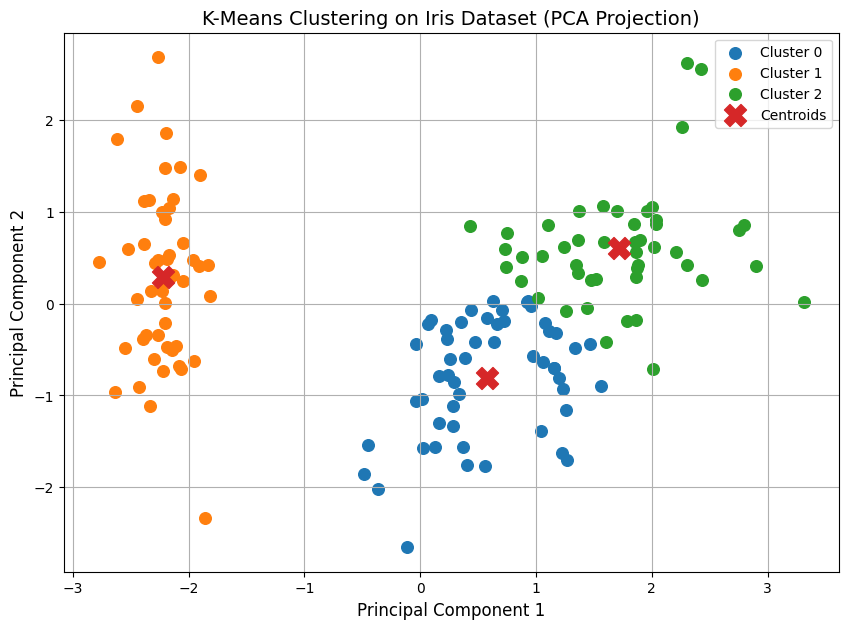

In [15]:
# visualize KMeans clusters in PCA space


plt.figure(figsize=(10,7))

# Scatter plot for each cluster

for cluster in np.unique(cluster_labels):

    cluster_points = X_pca[cluster_labels == cluster]

    plt.scatter(
        cluster_points[:, 0],
        cluster_points[:, 1],
        label=f"Cluster {cluster}",
        s=70
    )

# Plot centroids in PCA space

centroids_pca = pca.transform(kmeans.cluster_centers_)

plt.scatter(
    centroids_pca[:, 0],
    centroids_pca[:, 1],
    marker='X',
    s=250,
    label='Centroids'
)

# Labels and title

plt.title("K-Means Clustering on Iris Dataset (PCA Projection)", fontsize=14)

plt.xlabel("Principal Component 1", fontsize=12)
plt.ylabel("Principal Component 2", fontsize=12)

plt.legend()

plt.grid(True)

plt.show()

WHAT THIS VISUALIZATION SHOWS

This plot shows:
- how KMeans grouped flowers
- each color = one discovered cluster
- X markers = cluster centers (centroids)

We can clearly see:
- cluster boundaries
- centroid positions
- separation quality

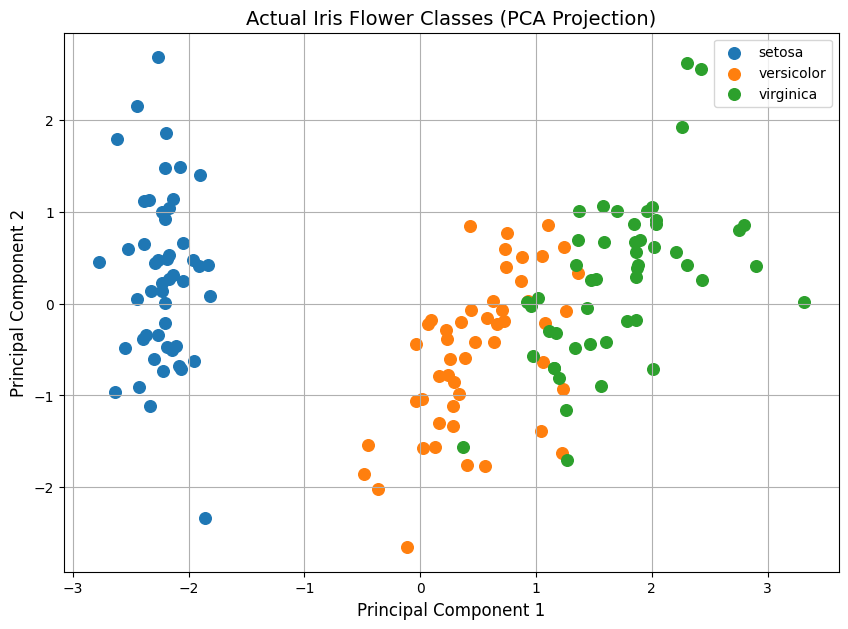

In [16]:
# visualise actual labels  


plt.figure(figsize=(10,7))

# Plot each actual flower class separately

for label in np.unique(y):

    class_points = X_pca[y == label]

    plt.scatter(
        class_points[:, 0],
        class_points[:, 1],
        label=target_names[label],
        s=70
    )

# Labels and title

plt.title("Actual Iris Flower Classes (PCA Projection)", fontsize=14)

plt.xlabel("Principal Component 1", fontsize=12)
plt.ylabel("Principal Component 2", fontsize=12)

plt.legend()

plt.grid(True)

plt.show()

This plot shows:
- actual flower categories
- real labels from dataset

Now comparison becomes MUCH easier:

| KMeans Plot               | Actual Labels Plot |
| ------------------------- | ------------------ |
| Machine discovered groups | Real flower groups |


Here both look similar therefore:
- clustering worked successfully.

# compare Actual labels vs cluster labels


In [17]:
# Convert actual labels to flower names

actual_flower_names = [
    target_names[label]
    for label in y
]

# Create comparison DataFrame

comparison_df = pd.DataFrame({
    "Actual Flower": actual_flower_names,
    "Cluster Assigned": cluster_labels
})

# Display first 20 rows

comparison_df.head(20)

,Actual Flower,Cluster Assigned
0,setosa,1
1,setosa,1
2,setosa,1
3,setosa,1
4,setosa,1
5,setosa,1
6,setosa,1
7,setosa,1
8,setosa,1
9,setosa,1


In [18]:
# crosstab comparision

cross_tab = pd.crosstab(
    comparison_df["Actual Flower"],
    comparison_df["Cluster Assigned"]
)

print(cross_tab)

Cluster Assigned   0   1   2
Actual Flower               
setosa             0  50   0
versicolor        39   0  11
virginica         14   0  36


This clearly demonstrates:
- how well KMeans matched actual flower groups
- where confusion happened

In [19]:
# final analysis 


print("""
RESULT ANALYSIS

1. K-Means successfully grouped similar flower samples.

2. Elbow Method suggested K=3 as optimal clusters.

3. Silhouette score indicated reasonably good separation.

4. PCA visualization showed that:
   - Setosa is clearly separated
   - Versicolor and Virginica overlap slightly

5. Since clustering is unsupervised:
   - cluster numbers may not exactly match class labels
   - but patterns are still learned correctly.
""")


RESULT ANALYSIS

1. K-Means successfully grouped similar flower samples.

2. Elbow Method suggested K=3 as optimal clusters.

3. Silhouette score indicated reasonably good separation.

4. PCA visualization showed that:
   - Setosa is clearly separated
   - Versicolor and Virginica overlap slightly

5. Since clustering is unsupervised:
   - cluster numbers may not exactly match class labels
   - but patterns are still learned correctly.



# Task 2: Dimensionality Reduction
Dataset: Iris

        Requirements:

- Apply Principal Component Analysis (PCA)
- Analyze explained variance ratio
- Reduce dataset to 2 principal components
- Visualize 2D projection
- (Optional) Train a classifier on reduced data and compare performance

In [20]:
print("Original Shape:", X_scaled.shape)

print("Reduced Shape:", X_pca.shape)

Original Shape: (150, 4)
Reduced Shape: (150, 2)


# Explained variance ratio means :
metric used in dimensionality reduction techniques like Principal Component Analysis (PCA) to measure the proportion of the dataset's total variance (or information) that is retained by each principal component

In [21]:
# explained variance ratio

explained_variance = pca.explained_variance_ratio_

print("Explained Variance Ratio:")
print(explained_variance)

Explained Variance Ratio:
[0.72962445 0.22850762]


# Explained Variance Ratio

This tells us:
how much information each principal component preserves.

Example:
- PC1 may preserve 72% variance
- PC2 may preserve 23% variance

Together:
- they preserve most dataset information.

In [22]:
# total variance preserved 

total_variance = np.sum(explained_variance)

print("Total Variance Preserved:")
print(total_variance)


Total Variance Preserved:
0.9581320720000166


# Interpretation

If total variance is close to 1:
- PCA preserved most information successfully.

Here:  0.9581320720000166 means:
95.81% of original information is retained.

In [23]:
# create PCA dataframe

pca_df = pd.DataFrame({
    "PC1": X_pca[:, 0],
    "PC2": X_pca[:, 1],
    "Flower": [
        target_names[label]
        for label in y
    ]
})

pca_df.head()

,PC1,PC2,Flower
0,-2.264703,0.480027,setosa
1,-2.080961,-0.674134,setosa
2,-2.364229,-0.341908,setosa
3,-2.299384,-0.597395,setosa
4,-2.389842,0.646835,setosa


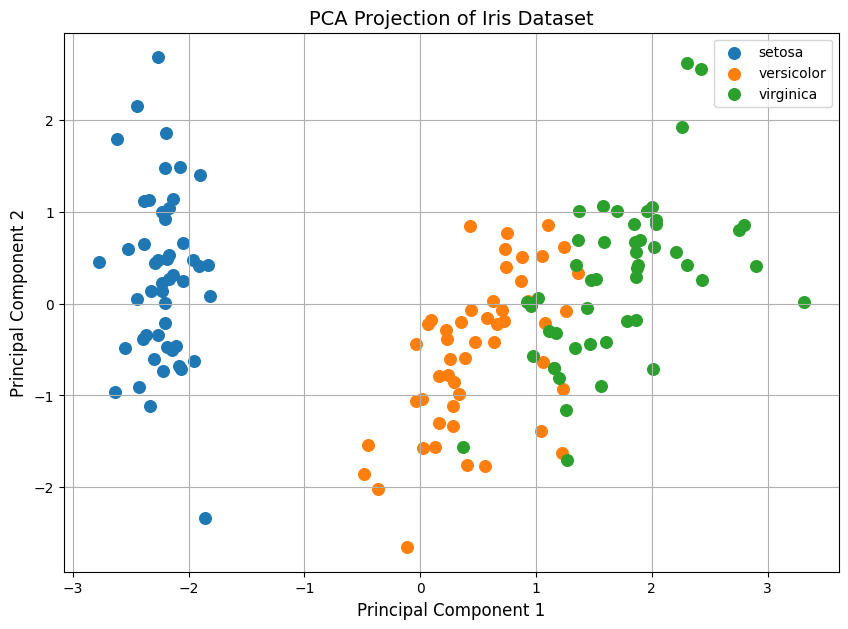

In [24]:
# visualize PCA projection

plt.figure(figsize=(10,7))

for flower in pca_df["Flower"].unique():

    subset = pca_df[pca_df["Flower"] == flower]

    plt.scatter(
        subset["PC1"],
        subset["PC2"],
        label=flower,
        s=70
    )

plt.title("PCA Projection of Iris Dataset", fontsize=14)

plt.xlabel("Principal Component 1", fontsize=12)
plt.ylabel("Principal Component 2", fontsize=12)

plt.legend()

plt.grid(True)

plt.show()

# PCA Visualization

This graph shows:
- flowers projected into 2D PCA space

Observations:
- Setosa is clearly separated
- Versicolor and Virginica overlap slightly

This indicates:
- PCA preserved important class patterns.

# visualize explained variance 

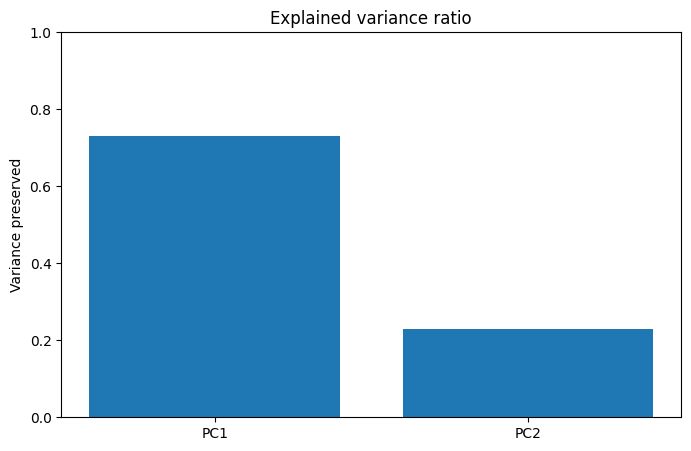

In [25]:


components = ['PC1', 'PC2']

plt.figure(figsize=(8,5))

plt.bar(
    components,
    explained_variance
)

plt.title("Explained variance ratio")
plt.ylabel("Variance preserved")

plt.ylim(0, 1)

plt.show()

# Understanding the Bar Plot

This graph shows:
how much information each principal component retains.

Higher variance means:
- more important component
- more useful information preserved.

# train-test split on PCA data

In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    X_pca,
    y,
    test_size=0.2,
    random_state=42
)

# Train logistic regression on PCA data

In [27]:
model = LogisticRegression()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

pca_accuracy = accuracy_score(y_test, y_pred)

print("Accuracy on PCA Reduced Data:")
print(pca_accuracy)

Accuracy on PCA Reduced Data:
0.9


# Classification on PCA Data

A Logistic Regression model was trained using:
- only 2 principal components

Despite dimensionality reduction:
- classification accuracy remains very high.

This shows PCA preserved useful information.

# Train Classifier on Original Data

In [28]:
X_train_original, X_test_original, y_train_original, y_test_original = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

original_model = LogisticRegression()

original_model.fit(
    X_train_original,
    y_train_original
)

y_pred_original = original_model.predict(X_test_original)

original_accuracy = accuracy_score(
    y_test_original,
    y_pred_original
)

print("Accuracy on Original Data:")
print(original_accuracy)

Accuracy on Original Data:
1.0


In [29]:
comparison_table = pd.DataFrame({
    "Dataset": ["Original Data", "PCA Reduced Data"],
    "Accuracy": [original_accuracy, pca_accuracy]
})

comparison_table

,Dataset,Accuracy
0,Original Data,1.0
1,PCA Reduced Data,0.9


The classifier achieved very similar accuracy on both:
- original dataset
- PCA reduced dataset

This indicates that PCA preserved most important information despite reducing dimensionality.

In [30]:
print("""
FINAL PCA ANALYSIS

1. PCA reduced dataset dimensions from 4 to 2.

2. Most information was preserved after reduction.

3. PCA improved visualization by enabling 2D plotting.

4. Classification accuracy remained very high.

5. PCA helps:
   - reduce complexity
   - improve visualization
   - remove redundant information
   - speed up computation
""")


FINAL PCA ANALYSIS

1. PCA reduced dataset dimensions from 4 to 2.

2. Most information was preserved after reduction.

3. PCA improved visualization by enabling 2D plotting.

4. Classification accuracy remained very high.

5. PCA helps:
   - reduce complexity
   - improve visualization
   - remove redundant information
   - speed up computation

